# Implementing Maximum Likelihood Estimation (MLE) for Different Distributions

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Maximum Likelihood Estimation for different distributions
- Understand the likelihood function and log-likelihood
- Estimate parameters using MLE for Gaussian, Poisson, and Bernoulli distributions
- Compare MLE estimates with true parameters

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 04 "Gradient Descent and Loss Functions" — minimizing a loss and maximizing a likelihood are the same move: MSE *is* the Gaussian log-likelihood.

**Used later in:** Course 08 (AIAT 122) — Unit 1 — cross-entropy loss, which every notebook there uses, is a negative log-likelihood.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Implementing Maximum Likelihood Estimation (MLE) for different distributions

---

## Introduction

**Maximum Likelihood Estimation (MLE)** is a method for estimating parameters of a probability distribution by maximizing the likelihood function, which measures how likely the observed data is given the parameter values.


---

## 📌 Real case: the principle that trains every model you will ever use

Ronald Fisher set out maximum likelihood in *"On the Mathematical Foundations of Theoretical Statistics"*
(Philosophical Transactions of the Royal Society A, 222, 1922) — reference 1 at the foot of this notebook.
The idea is one sentence: among all the parameter values you could have chosen, pick the one that makes
the data you actually observed most probable.

A century later, that sentence is still the objective function of the field. Training a language model
means maximising the likelihood of the next token given the previous ones — which is exactly what
"minimise cross-entropy loss" means, because cross-entropy is the negative log-likelihood. Fitting a
logistic regression is maximum likelihood. Fitting a linear regression by minimising mean squared error is
maximum likelihood **under an assumption of Gaussian noise** (Unit 5, notebook 09 verifies that assumption
on real residuals). When you type `model.fit(X, y)`, this 1922 principle is what runs.

**What goes wrong without this.** Without it, "which loss should I use?" is a matter of taste. With it, the
loss is *derived*: state what distribution you believe generated the data, write down its likelihood, take
the negative log, and you have your loss function — along with a clear statement of the assumption you just
made, which is the part people skip.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib, scipy.stats for distributions, SciPy's optimizers, and
# sklearn plus the shared data loader for the REAL datasets we estimate parameters from.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar, minimize
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------------------------


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nImplementing Maximum Likelihood Estimation (MLE)")
print("=" * 60)


✅ Libraries imported!

Implementing Maximum Likelihood Estimation (MLE)


## Part 1: MLE for Gaussian Distribution


Part 1: MLE for Gaussian Distribution

Real measurements: mean texture of 569 tumour biopsies
 Range: 9.71 to 39.28

MLE estimates (closed form):
 μ_MLE (sample mean): 19.2896
 σ_MLE (sample std): 4.2973

MLE from numerical optimization (started far away, at μ=9.7, σ=1):
 μ_MLE: 19.2896
 σ_MLE: 4.2973
 Agreement with the formula: Δμ = 4.50e-08, Δσ = 1.38e-07

Log-likelihood at the MLE:            -1636.96
Log-likelihood at μ=22.29 (3 units off): -1775.62  <- lower, as it must be


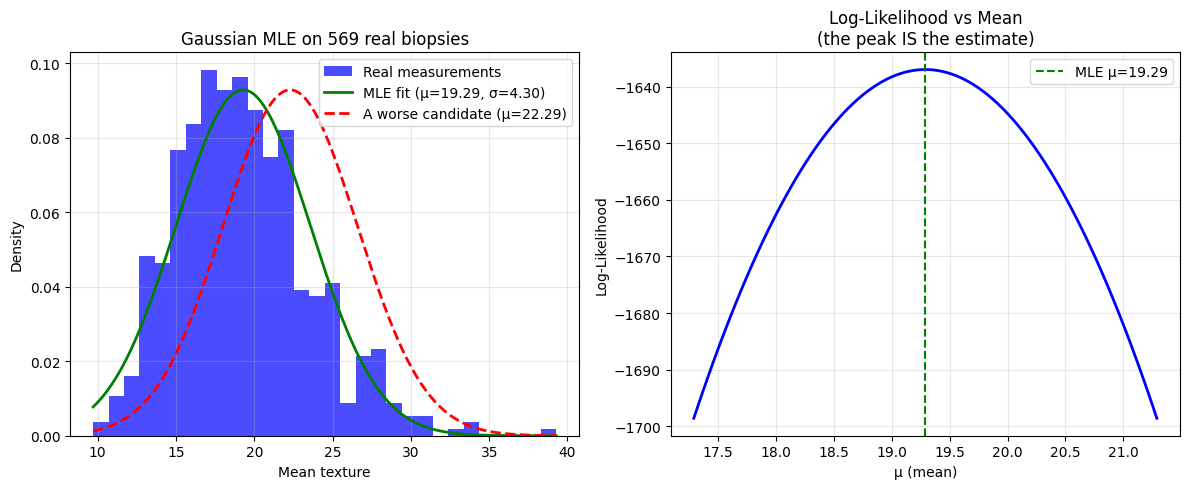


📊 Read the figure:
  - Left: two Normal curves over the same histogram. The green one is the MLE; the red
    dashed one has the same σ but a mean 3 units too high, and you can SEE it
    paying for that - it sits above the data on the right and below it on the left.
    Its log-likelihood is 139 lower, i.e. it makes the observed 569 biopsies
    e^139 times less probable. 'Maximum likelihood' is exactly this comparison,
    run over every candidate.
  - Right: that comparison as a curve. Every μ on the x-axis is one candidate model;
    the height is how well it explains the data; the green line is the winner.

Fit check - Shapiro-Wilk normality test on the same data: p = 7.28e-08
The Normal family is a good working model here, but not a perfect one. MLE finds the
BEST Normal for this data; whether a Normal was the right shape is a separate question.

✅ MLE for Gaussian distribution implemented on real data!


In [2]:
# MLE for a Gaussian on REAL measurements: the closed-form answers (sample mean/std)
# versus SciPy's numerical optimizer. Both maximize the same log-likelihood - the optimizer
# just does not know the shortcut.
#
# Important shift from a textbook demo: with real data there is NO "true mu" to recover.
# MLE answers a different question - "which Normal makes what I observed most likely?"

print("=" * 60)
print("Part 1: MLE for Gaussian Distribution")
print("=" * 60)

# Real data: "mean texture" measured on 569 breast-tumour biopsies (the standard deviation
# of grey-scale values in each digitised tumour image).
cancer = load_breast_cancer()
data = cancer.data[:, list(cancer.feature_names).index("mean texture")]

print(f"\nReal measurements: mean texture of {len(data)} tumour biopsies")
print(f" Range: {data.min():.2f} to {data.max():.2f}")

# MLE for Gaussian: sample mean and sample std
mle_mu = np.mean(data)
mle_sigma = np.std(data, ddof=0)  # MLE uses N, not N-1

print(f"\nMLE estimates (closed form):")
print(f" μ_MLE (sample mean): {mle_mu:.4f}")
print(f" σ_MLE (sample std): {mle_sigma:.4f}")

# Negative log-likelihood function (we minimize this)
def neg_log_likelihood_gaussian(params, data):
    """Negative log-likelihood for Gaussian distribution"""
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    n = len(data)
    log_likelihood = -n * np.log(sigma * np.sqrt(2 * np.pi)) - np.sum((data - mu)**2) / (2 * sigma**2)
    return -log_likelihood  # Return negative for minimization

# Optimize using scipy, starting from a deliberately poor guess so the search has work to do.
# We also record every step the optimizer takes: the next cell draws that climb.
start_point = np.array([data.min(), 1.0])
search_path = [start_point]
result = minimize(lambda p: neg_log_likelihood_gaussian(p, data),
                  x0=start_point,
                  method='BFGS',
                  callback=lambda xk: search_path.append(np.array(xk)))
search_path = np.array(search_path)
mle_mu_opt = result.x[0]
mle_sigma_opt = result.x[1]
print(f"\nMLE from numerical optimization (started far away, at μ={data.min():.1f}, σ=1):")
print(f" μ_MLE: {mle_mu_opt:.4f}")
print(f" σ_MLE: {mle_sigma_opt:.4f}")
print(f" Agreement with the formula: Δμ = {abs(mle_mu_opt - mle_mu):.2e}, "
      f"Δσ = {abs(mle_sigma_opt - mle_sigma):.2e}")

# A deliberately worse candidate, to show what "maximum" means
worse_mu, worse_sigma = mle_mu + 3.0, mle_sigma
ll_best = -neg_log_likelihood_gaussian([mle_mu, mle_sigma], data)
ll_worse = -neg_log_likelihood_gaussian([worse_mu, worse_sigma], data)
print(f"\nLog-likelihood at the MLE:            {ll_best:.2f}")
print(f"Log-likelihood at μ={worse_mu:.2f} (3 units off): {ll_worse:.2f}  <- lower, as it must be")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(data, bins=30, density=True, alpha=0.7, color='blue', label='Real measurements')
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, stats.norm.pdf(x, mle_mu, mle_sigma), 'g-', linewidth=2,
         label=f'MLE fit (μ={mle_mu:.2f}, σ={mle_sigma:.2f})')
plt.plot(x, stats.norm.pdf(x, worse_mu, worse_sigma), 'r--', linewidth=2,
         label=f'A worse candidate (μ={worse_mu:.2f})')
plt.xlabel('Mean texture')
plt.ylabel('Density')
plt.title('Gaussian MLE on 569 real biopsies')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
mu_range = np.linspace(mle_mu - 2, mle_mu + 2, 100)
log_likelihoods = [-neg_log_likelihood_gaussian([mu, mle_sigma], data) for mu in mu_range]
plt.plot(mu_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_mu, color='g', linestyle='--', label=f'MLE μ={mle_mu:.2f}')
plt.xlabel('μ (mean)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs Mean\n(the peak IS the estimate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print("  - Left: two Normal curves over the same histogram. The green one is the MLE; the red")
print(f"    dashed one has the same σ but a mean {worse_mu - mle_mu:.0f} units too high, and you can SEE it")
print("    paying for that - it sits above the data on the right and below it on the left.")
print(f"    Its log-likelihood is {ll_best - ll_worse:.0f} lower, i.e. it makes the observed 569 biopsies")
print(f"    e^{ll_best - ll_worse:.0f} times less probable. 'Maximum likelihood' is exactly this comparison,")
print("    run over every candidate.")
print("  - Right: that comparison as a curve. Every μ on the x-axis is one candidate model;")
print("    the height is how well it explains the data; the green line is the winner.")

# Honest postscript: MLE picks the best member of a family; it cannot tell you the
# family was the right choice.
print(f"\nFit check - Shapiro-Wilk normality test on the same data: p = {stats.shapiro(data).pvalue:.2e}")
print("The Normal family is a good working model here, but not a perfect one. MLE finds the")
print("BEST Normal for this data; whether a Normal was the right shape is a separate question.")

print("\n✅ MLE for Gaussian distribution implemented on real data!")


### 🎬 Watching the estimate being found

The two numbers above arrived instantly because a Gaussian has a closed-form answer. Almost
nothing else you will fit does — a neural network has no formula for its weights, only a search.
The optimizer above *did* search, starting from a deliberately bad guess, and it recorded every
step on the way. The cell below replays that climb, which is the same picture you will meet
again as gradient descent.

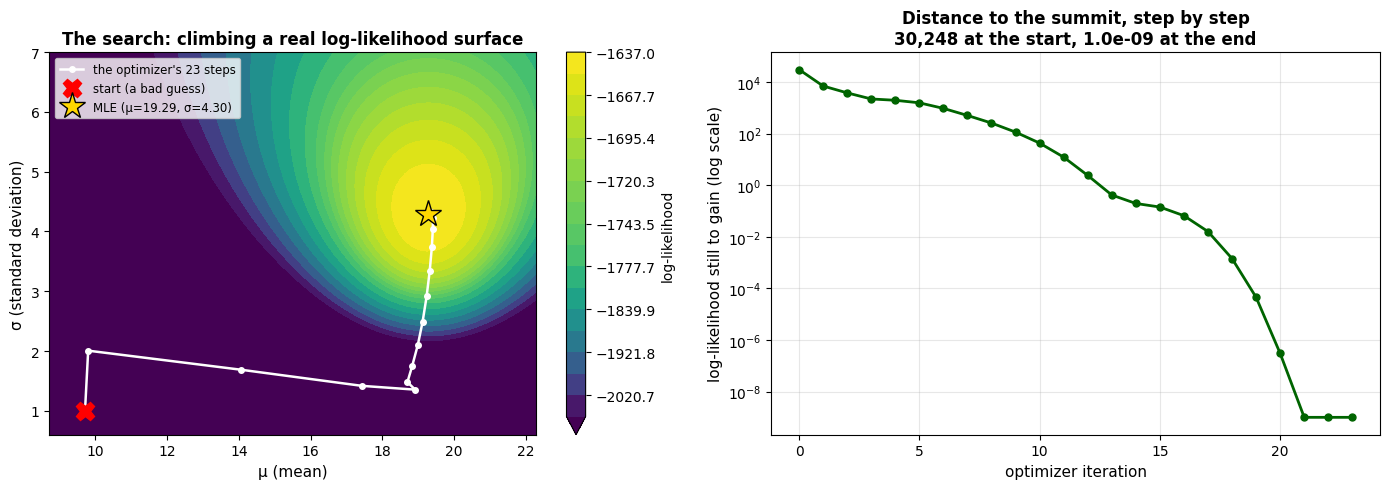

Step table (a sample of the climb):
 iteration         μ         σ    log-likelihood    gap to peak
----------------------------------------------------------------
         0     9.710     1.000          -31885.0      30248.071
         1     9.798     2.006           -8592.7       6955.734
         2    14.055     1.688           -5402.5       3765.565
         3    17.435     1.417           -3824.0       2187.015
         5    18.702     1.481           -3187.5       1550.557
         8    19.124     2.487           -1892.0        255.054
        12    19.412     4.048           -1639.3          2.376
        23    19.290     4.297           -1637.0          0.000

📊 Read the figure:
  - Left: brighter is better. The red X is the deliberately bad starting guess
    (μ=9.7, σ=1.0); the white line is the route the optimizer actually took;
    the gold star is the answer the closed-form formula gives. They coincide - the
    search finds what the algebra already knew, which is the poi

In [3]:
# STEP STORYBOARD of the search: where the optimizer stood at each iteration.
# WHY draw it: "maximum likelihood" sounds like a formula, but for most models it is a WALK
# uphill on a surface. Here the surface is real (569 biopsies) and so is the walk.

# The log-likelihood surface over the two parameters, evaluated on a grid.
mu_grid = np.linspace(data.min() - 1, mle_mu + 3, 90)
sigma_grid = np.linspace(0.6, 7.0, 90)
MU, SIG = np.meshgrid(mu_grid, sigma_grid)
n_obs = len(data)
# Vectorised log-likelihood: -n·log(σ√2π) - Σ(x-μ)² / 2σ²
sum_sq = np.array([np.sum((data - m) ** 2) for m in mu_grid])[None, :]
LL = -n_obs * np.log(SIG * np.sqrt(2 * np.pi)) - sum_sq / (2 * SIG ** 2)

ll_at = lambda p: -neg_log_likelihood_gaussian(p, data)
ll_path = np.array([ll_at(p) for p in search_path])
ll_peak = ll_at([mle_mu, mle_sigma])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: the surface, with the optimizer's route drawn on it ------------------------------
# Contour levels are placed by quantile, so the detail lands near the summit instead of being
# swallowed by the enormous drop-off at bad parameter values.
levels = np.quantile(LL, np.linspace(0.55, 1.0, 18))
cf = axes[0].contourf(MU, SIG, LL, levels=levels, cmap='viridis', extend='min')
fig.colorbar(cf, ax=axes[0], label='log-likelihood')
axes[0].plot(search_path[:, 0], search_path[:, 1], 'o-', color='white', linewidth=1.8,
             markersize=4, label=f'the optimizer\'s {len(search_path) - 1} steps')
axes[0].plot(*search_path[0], 'X', color='red', markersize=13, label='start (a bad guess)')
axes[0].plot(mle_mu, mle_sigma, '*', color='gold', markersize=20, markeredgecolor='black',
             label=f'MLE (μ={mle_mu:.2f}, σ={mle_sigma:.2f})')
axes[0].set_xlabel('μ (mean)', fontsize=11)
axes[0].set_ylabel('σ (standard deviation)', fontsize=11)
axes[0].set_title('The search: climbing a real log-likelihood surface',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5, loc='upper left')

# --- Right: how far below the summit each step still was ------------------------------------
gap = np.maximum(ll_peak - ll_path, 1e-9)
axes[1].plot(np.arange(len(gap)), gap, 'o-', color='darkgreen', linewidth=2, markersize=5)
axes[1].set_yscale('log')
axes[1].set_xlabel('optimizer iteration', fontsize=11)
axes[1].set_ylabel('log-likelihood still to gain (log scale)', fontsize=11)
axes[1].set_title('Distance to the summit, step by step\n'
                  f'{gap[0]:,.0f} at the start, {gap[-1]:.1e} at the end',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# The step table: a few frames of the same climb, in numbers.
show = sorted(set([0, 1, 2, 3, 5, 8, 12, len(search_path) - 1]))
print("Step table (a sample of the climb):")
print(f"{'iteration':>10} {'μ':>9} {'σ':>9} {'log-likelihood':>17} {'gap to peak':>14}")
print("-" * 64)
for i in show:
    if i < len(search_path):
        print(f"{i:>10} {search_path[i, 0]:>9.3f} {search_path[i, 1]:>9.3f} "
              f"{ll_path[i]:>17.1f} {ll_peak - ll_path[i]:>14.3f}")

print("\n📊 Read the figure:")
print("  - Left: brighter is better. The red X is the deliberately bad starting guess")
print(f"    (μ={search_path[0, 0]:.1f}, σ=1.0); the white line is the route the optimizer actually took;")
print("    the gold star is the answer the closed-form formula gives. They coincide - the")
print("    search finds what the algebra already knew, which is the point of the check.")
print("  - The route has three distinct legs: straight UP in σ, then a long run RIGHT along")
print("    the bottom to the correct μ, then a second climb UP in σ to the star. That shape")
print("    is the surface talking: with σ far too small every observation looks impossible,")
print("    so the first repair is always the spread.")
print(f"  - Right: the gap to the summit falls from {gap[0]:,.0f} to {gap[-1]:.1e}. The curve is nearly")
print("    FLAT for the first few iterations - that is the long run across the dark plain on")
print("    the left panel, where the surface is almost level and progress is slow - and then")
print(f"    it plunges once the search is near the peak. The last {len(gap) - 1 - int(np.argmax(gap < 1e-3))} iterations buy less than")
print("    0.001 of log-likelihood: convergence, and the reason optimizers stop.")


**📖 What to see in the figure above.** The left panel is the thing "maximum
likelihood" actually means when there is no formula: a surface over the parameters, and a walk
uphill on it. The white track starts at the red X — a guess that is wrong on purpose — and ends
on the gold star, which is where the closed-form answer sits, so the two methods agree. The
shape of the track is informative in itself: it fixes σ first, then travels sideways to the
right μ, then climbs to the summit, because a model whose spread is far too small assigns
almost zero probability to the data and is punished harder than one whose centre is slightly
off. The right panel is the same climb measured: the remaining distance to the summit barely
moves while the search crosses the flat dark region, then falls by nine orders of magnitude
near the peak and flattens — which is what "converged" looks like and why the optimizer
stops.

## Part 2: MLE for Poisson Distribution



Part 2: MLE for Poisson Distribution
titanic: full file, 891 rows.

Real data: siblings or spouses aboard, one count per passenger
 Passengers observed: 891
 Counts range from 0 to 8 per passenger
 Travelling with none at all: 608 passengers (68.2%)

MLE estimate:
 λ_MLE (sample mean): 0.5230 siblings/spouses per passenger
 λ from numerical optimization: 0.5230  (matches the sample mean)


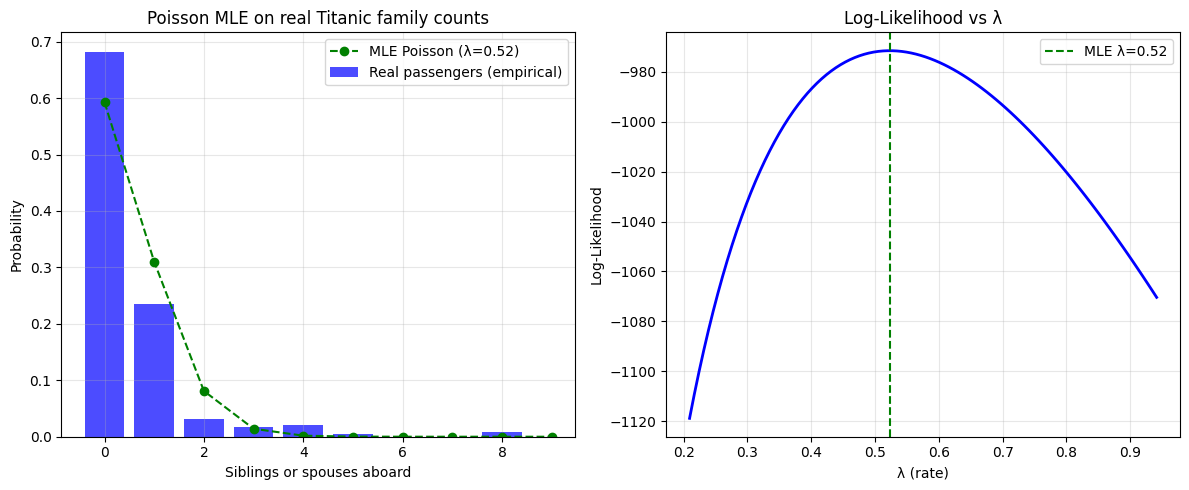


Model check - a Poisson distribution must have variance = mean:
  sample mean:     0.523
  sample variance: 1.215
  ratio: 2.32
  passengers with 4 or more siblings/spouses aboard: 30 observed, 1.8 expected under this Poisson
Real family sizes are strongly OVER-dispersed, and the reason is checkable in the file:
all 7 passengers recorded with 8 siblings aboard are the Sage family on one ticket
(CA. 2343), and all 5 recorded with 5 are the Goodwins on ticket CA 2144. A Poisson
assumes each count is an independent draw; these counts arrive in whole families.
MLE still returns the best lambda, and reports no complaint about the wrong family.

📊 Read the figure:
  - Left: the green Poisson curve is the best Poisson there is, and it still misses in
    a pattern. At 0 the blue bar stands ABOVE the curve (0.682 observed against
    0.593 predicted) - more passengers travelled alone than a Poisson allows.
    At 1 and 2 the curve sits above the bars. Then from 4 rightwards the bars reappear


In [4]:
# MLE for a Poisson on REAL count data: the sample mean again turns out to be the
# maximum-likelihood answer. The right panel shows the log-likelihood peaking exactly there.

print("\n" + "=" * 60)
print("Part 2: MLE for Poisson Distribution")
print("=" * 60)

# Real counts: how many siblings or spouses each RMS Titanic passenger travelled with
# (the SibSp column). A Poisson is the default first model for ANY count, and this file
# ships whole with the repository, so every number below is the same on every machine:
# no download, no sample, no network. That matters here, because the whole point of this
# section is a variance-to-mean ratio, and a ratio computed from a thinned sample of a
# bigger file would be an artefact of the thinning rather than a fact about the world.
titanic = load("titanic")
data_poisson = titanic["SibSp"].to_numpy()

print(f"\nReal data: siblings or spouses aboard, one count per passenger")
print(f" Passengers observed: {len(data_poisson)}")
print(f" Counts range from {data_poisson.min()} to {data_poisson.max()} per passenger")
print(f" Travelling with none at all: {(data_poisson == 0).sum()} passengers "
      f"({(data_poisson == 0).mean():.1%})")

# MLE for Poisson: sample mean
mle_lambda = np.mean(data_poisson)

print(f"\nMLE estimate:")
print(f" \u03bb_MLE (sample mean): {mle_lambda:.4f} siblings/spouses per passenger")

# Negative log-likelihood
def neg_log_likelihood_poisson(lambda_param, data):
    """Negative log-likelihood for Poisson distribution"""
    if lambda_param <= 0:
        return np.inf
    from scipy.special import gammaln
    n = len(data)
    log_likelihood = np.sum(data) * np.log(lambda_param) - n * lambda_param - np.sum(gammaln(np.array(data) + 1))
    return -log_likelihood

# Cross-check the formula against a numerical search
opt = minimize_scalar(lambda lam: neg_log_likelihood_poisson(lam, data_poisson),
                      bounds=(0.01, 50), method='bounded')
print(f" \u03bb from numerical optimization: {opt.x:.4f}  (matches the sample mean)")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
unique, counts = np.unique(data_poisson, return_counts=True)
plt.bar(unique, counts / len(data_poisson), alpha=0.7, color='blue', label='Real passengers (empirical)')
x = np.arange(0, max(unique) + 2)
plt.plot(x, stats.poisson.pmf(x, mle_lambda), 'go--', markersize=6, label=f'MLE Poisson (\u03bb={mle_lambda:.2f})')
plt.xlabel('Siblings or spouses aboard')
plt.ylabel('Probability')
plt.title('Poisson MLE on real Titanic family counts')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# The window is scaled to lambda. A fixed +/- 2 window would push a peak this small
# off the left edge of the axes and hide the very thing the panel exists to show.
lambda_range = np.linspace(mle_lambda * 0.4, mle_lambda * 1.8, 100)
log_likelihoods = [-neg_log_likelihood_poisson(lam, data_poisson) for lam in lambda_range]
plt.plot(lambda_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_lambda, color='g', linestyle='--', label=f'MLE \u03bb={mle_lambda:.2f}')
plt.xlabel('\u03bb (rate)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs \u03bb')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Honest model check: a Poisson has variance equal to its mean.
big = int((data_poisson >= 4).sum())
big_expected = (1 - stats.poisson.cdf(3, mle_lambda)) * len(data_poisson)
print(f"\nModel check - a Poisson distribution must have variance = mean:")
print(f"  sample mean:     {data_poisson.mean():.3f}")
print(f"  sample variance: {data_poisson.var():.3f}")
print(f"  ratio: {data_poisson.var() / data_poisson.mean():.2f}")
print(f"  passengers with 4 or more siblings/spouses aboard: {big} observed, "
      f"{big_expected:.1f} expected under this Poisson")
print("Real family sizes are strongly OVER-dispersed, and the reason is checkable in the file:")
print("all 7 passengers recorded with 8 siblings aboard are the Sage family on one ticket")
print("(CA. 2343), and all 5 recorded with 5 are the Goodwins on ticket CA 2144. A Poisson")
print("assumes each count is an independent draw; these counts arrive in whole families.")
print("MLE still returns the best lambda, and reports no complaint about the wrong family.")

print("\n\U0001F4CA Read the figure:")
print("  - Left: the green Poisson curve is the best Poisson there is, and it still misses in")
print(f"    a pattern. At 0 the blue bar stands ABOVE the curve ({(data_poisson == 0).mean():.3f} observed against")
print(f"    {stats.poisson.pmf(0, mle_lambda):.3f} predicted) - more passengers travelled alone than a Poisson allows.")
print("    At 1 and 2 the curve sits above the bars. Then from 4 rightwards the bars reappear")
print(f"    where the curve has already died: {big} passengers observed against {big_expected:.1f} expected,")
print(f"    roughly {big / big_expected:.0f} times too many. Too many zeros AND too many extremes at once is")
print(f"    what a variance-to-mean ratio of {data_poisson.var() / data_poisson.mean():.2f} looks like drawn.")
print("  - Right: the log-likelihood as \u03bb is varied, with a single smooth peak at the green")
print("    line. 'Maximum likelihood' is that peak, and nothing else in the picture.")

print("\n\u2705 MLE for Poisson distribution implemented on real data!")


## Part 3: MLE for Bernoulli Distribution



Part 3: MLE for Bernoulli Distribution
titanic: full file, 891 rows.

Real data: survival of 891 Titanic passengers
 Number of survivors: 342
 Number who died: 549

MLE estimate:
 p_MLE (sample proportion): 0.3838  ->  a 38.4% survival rate


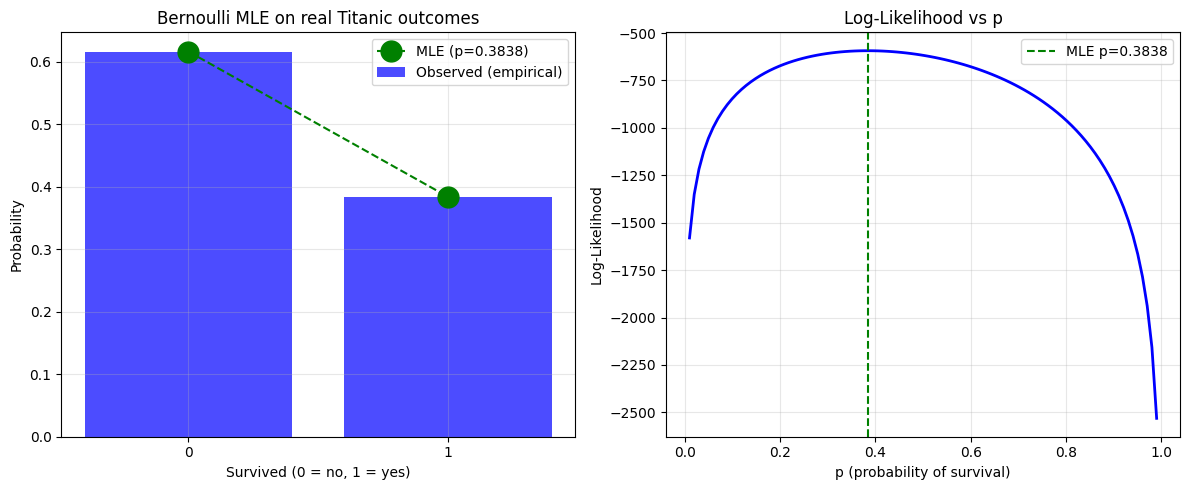


A single p treats every passenger alike. The real data does not:
  p_MLE for female passengers: 0.7420
  p_MLE for   male passengers: 0.1889
Fitting one Bernoulli PER GROUP is already a (very simple) classifier - and the
gap between these two numbers is why 'sex' is the single strongest Titanic feature.

📊 Read the figure:
  - Left: two bars, and the two green MLE dots sit exactly on top of them. For a
    Bernoulli, the maximum-likelihood answer IS the observed fraction - there is
    nothing left to estimate once you have counted.
  - Right: the log-likelihood over p, falling away on both sides of the green line and
    plunging near p=0 and p=1. The dome looks gentle at this scale, so read it in
    numbers instead: shifting p by just 0.05 makes the observed 891 outcomes about
    98 times less likely. That is what a large sample buys - a peak that is
    narrow in evidence even when it looks broad on the page.

✅ MLE for Bernoulli distribution implemented on real data!


In [5]:
# MLE for a Bernoulli on a REAL binary outcome: the observed success fraction maximizes
# the likelihood. This is the same math that calibrates a classifier's predicted probabilities.

print("\n" + "=" * 60)
print("Part 3: MLE for Bernoulli Distribution")
print("=" * 60)

# Real binary outcome: did each of the 891 passengers on the RMS Titanic survive?
titanic = load("titanic")
data_bernoulli = titanic["Survived"].to_numpy()

print(f"\nReal data: survival of {len(data_bernoulli)} Titanic passengers")
print(f" Number of survivors: {data_bernoulli.sum()}")
print(f" Number who died: {len(data_bernoulli) - data_bernoulli.sum()}")

# MLE for Bernoulli: sample proportion
mle_p = np.mean(data_bernoulli)

print(f"\nMLE estimate:")
print(f" p_MLE (sample proportion): {mle_p:.4f}  ->  a {mle_p:.1%} survival rate")

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
unique, counts = np.unique(data_bernoulli, return_counts=True)
plt.bar(unique, counts / len(data_bernoulli), alpha=0.7, color='blue', label='Observed (empirical)')
x = np.array([0, 1])
plt.plot(x, stats.bernoulli.pmf(x, mle_p), 'go--', markersize=15, label=f'MLE (p={mle_p:.4f})')
plt.xlabel('Survived (0 = no, 1 = yes)')
plt.ylabel('Probability')
plt.title('Bernoulli MLE on real Titanic outcomes')
plt.xticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
p_range = np.linspace(0.01, 0.99, 100)
# Log-likelihood: k*log(p) + (n-k)*log(1-p) where k = sum(data)
k = data_bernoulli.sum()
n = len(data_bernoulli)
log_likelihoods = k * np.log(p_range) + (n - k) * np.log(1 - p_range)
plt.plot(p_range, log_likelihoods, 'b-', linewidth=2)
plt.axvline(mle_p, color='g', linestyle='--', label=f'MLE p={mle_p:.4f}')
plt.xlabel('p (probability of survival)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs p')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# One Bernoulli for everyone is the simplest possible model. Real survival was not uniform.
by_sex = titanic.groupby("Sex")["Survived"].mean()
print(f"\nA single p treats every passenger alike. The real data does not:")
for sex, rate in by_sex.items():
    print(f"  p_MLE for {sex:>6} passengers: {rate:.4f}")
print("Fitting one Bernoulli PER GROUP is already a (very simple) classifier - and the")
print("gap between these two numbers is why 'sex' is the single strongest Titanic feature.")

print("\n📊 Read the figure:")
print(f"  - Left: two bars, and the two green MLE dots sit exactly on top of them. For a")
print("    Bernoulli, the maximum-likelihood answer IS the observed fraction - there is")
print("    nothing left to estimate once you have counted.")
# How much worse is a candidate 0.05 away from the MLE? Turn log-likelihood into odds.
_ll = lambda p: k * np.log(p) + (n - k) * np.log(1 - p)
_ratio = np.exp(_ll(mle_p) - _ll(mle_p + 0.05))
print("  - Right: the log-likelihood over p, falling away on both sides of the green line and")
print("    plunging near p=0 and p=1. The dome looks gentle at this scale, so read it in")
print(f"    numbers instead: shifting p by just 0.05 makes the observed 891 outcomes about")
print(f"    {_ratio:,.0f} times less likely. That is what a large sample buys - a peak that is")
print("    narrow in evidence even when it looks broad on the page.")

print("\n✅ MLE for Bernoulli distribution implemented on real data!")


---

## ⚠️ Where this breaks

- **MLE finds the best member of a family. It cannot tell you the family is wrong.** Every part of this
  notebook demonstrates it. The Gaussian fit to tumour textures is the best possible Normal — and
  Shapiro–Wilk on the same data returns **p = 7.28 × 10⁻⁸**. The Poisson fit to how many siblings or spouses
  each Titanic passenger travelled with gives λ = 0.5230 — and the data's variance is **1.215** against a
  mean of 0.523, a ratio of **2.32**, when a Poisson requires them to be equal. It shows up as a concrete
  miss: **30** passengers had four or more siblings/spouses aboard where this Poisson expects **1.8**.
  The cause is checkable in the file — all seven passengers recorded with 8 siblings are the Sage family
  on ticket CA. 2343, and all five recorded with 5 are the Goodwins on ticket CA 2144. Counts that arrive
  in whole families are not independent draws. MLE gave the best λ for a model that is not true, and
  reported no complaint.
- **The MLE of the standard deviation is biased.** The formula that maximises the likelihood divides by n;
  the unbiased estimator divides by n − 1. At n = 569 the difference is invisible. At n = 5 it is not.
  "Maximum likelihood" and "unbiased" are different criteria and they disagree.
- **A single fitted parameter can hide the structure that matters.** The Bernoulli fit gives
  p = 0.3838 for Titanic survival — one number for 891 people. Split by sex and it becomes **0.7420 for
  women and 0.1889 for men**. The single-p model is not wrong, it is *uninformative*: it maximises the
  likelihood of a model that assumes everyone was alike, and that assumption is where the whole story was.
  Fitting one distribution per group is already a classifier.
- **Cheaper alternative when the family is doubtful.** For counts that are over-dispersed, the negative
  binomial adds one parameter and fixes exactly the 2.32 ratio above. For distributions you cannot name,
  the empirical distribution and the bootstrap assume nothing.


---

## 💬 Discuss

1. The Titanic sibling/spouse counts have variance 2.32× their mean, which a Poisson forbids. The MLE
   still returned a λ and no warning. Whose job is it to notice, and what specific check would you make
   routine so that it *is* noticed?
2. One Bernoulli p for the Titanic (0.3838) hides a 0.742 / 0.189 split by sex. How would you decide, in
   general, when a single pooled estimate is a useful summary and when it is a misleading one?
3. Cross-entropy loss is the negative log-likelihood of a categorical model. Given that, what assumption
   are you making every time you train a classifier with cross-entropy — and can you name a situation where
   it is clearly false?


## Summary

### Key Concepts:
1. **Likelihood Function**: Measures probability of observing data given parameters
2. **Maximum Likelihood Estimation**: Finds parameters that maximize likelihood
3. **Log-Likelihood**: Often easier to work with (converts products to sums)
4. **MLE for Common Distributions**:
   - Gaussian: sample mean and sample std
   - Poisson: sample mean
   - Bernoulli: sample proportion

### Best Practices:
- Use log-likelihood to avoid numerical underflow
- Verify constraints (e.g., σ > 0, 0 < p < 1)
- Compare MLE estimates with true parameters
- Understand when MLE is appropriate

### Applications:
- Parameter estimation
- Model fitting
- Statistical inference
- Machine learning (loss functions)

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - Maximum Likelihood Estimation practical content

## 📚 References

1. Fisher, R. A. (1922). *On the Mathematical Foundations of Theoretical Statistics*. Philosophical Transactions of the Royal Society A, 222, 309–368.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 5: Machine Learning Basics (Maximum Likelihood Estimation). MIT Press. <https://www.deeplearningbook.org/>
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>
4. Papamarkou, T., Skoularidou, M., Palla, K., Aitchison, L., Arbel, J., et al. (2024). *Position: Bayesian Deep Learning is Needed in the Age of Large-Scale AI*. arXiv. <https://arxiv.org/abs/2402.00809> — the case against reporting only the maximum-likelihood point estimate for large models.
5. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — the 2025 map of uncertainty methods that start where a single MLE fit ends.
